In [460]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor


from prophet import Prophet
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
import itertools

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

import warnings
warnings.filterwarnings('ignore')

In [461]:
# Load the data
df_train = pd.read_csv("./dataset/train.csv")
df_fullfilment = pd.read_csv("./dataset/fulfilment_center_info.csv")
df_meal = pd.read_csv("./dataset/meal_info.csv")
df_test = pd.read_csv("./dataset/test.csv")

In [462]:
print(f"Train data: {df_train.shape}")
print(f"Test data: {df_test.shape}")
print(f"Fullfilment_center_info data: {df_fullfilment.shape}")
print(f"Meal_info data: {df_meal.shape}")

Train data: (456548, 9)
Test data: (32573, 8)
Fullfilment_center_info data: (77, 5)
Meal_info data: (51, 3)


In [463]:
df_train.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [464]:
df_test.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured
0,1028232,146,55,1885,158.11,159.11,0,0
1,1127204,146,55,1993,160.11,159.11,0,0
2,1212707,146,55,2539,157.14,159.14,0,0
3,1082698,146,55,2631,162.02,162.02,0,0
4,1400926,146,55,1248,163.93,163.93,0,0


In [465]:
df_fullfilment.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [466]:
df_meal.head()

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [467]:
df_train.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000


In [468]:
df_train.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64

In [469]:
print(df_test.shape)
df_test = df_test.merge(df_fullfilment, on="center_id", how='left')
df_test = df_test.merge(df_meal, on="meal_id", how="left")
print(df_test.shape)
df_test.head()

(32573, 8)
(32573, 14)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,city_code,region_code,center_type,op_area,category,cuisine
0,1028232,146,55,1885,158.11,159.11,0,0,647,56,TYPE_C,2.0,Beverages,Thai
1,1127204,146,55,1993,160.11,159.11,0,0,647,56,TYPE_C,2.0,Beverages,Thai
2,1212707,146,55,2539,157.14,159.14,0,0,647,56,TYPE_C,2.0,Beverages,Thai
3,1082698,146,55,2631,162.02,162.02,0,0,647,56,TYPE_C,2.0,Beverages,Indian
4,1400926,146,55,1248,163.93,163.93,0,0,647,56,TYPE_C,2.0,Beverages,Indian


In [470]:
print(df_train.shape)
df_train = df_train.merge(df_fullfilment, on="center_id", how='left')
df_train = df_train.merge(df_meal, on="meal_id", how="left")
print(df_train.shape)
df_train.head()

(456548, 9)
(456548, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


In [471]:
df_temp = df_train.groupby(by="category").agg({"cuisine": "nunique"}).reset_index()
df_temp

,category,cuisine
0,Beverages,4
1,Biryani,1
2,Desert,1
3,Extras,1
4,Fish,1
5,Other Snacks,1
6,Pasta,1
7,Pizza,1
8,Rice Bowl,1
9,Salad,1


### Observation
* Other than 'Beverages', all other categories are unique to their cuisine

In [472]:
df_temp = df_train.groupby(by="center_id").agg({"cuisine": "nunique"}).reset_index().sort_values('cuisine')
df_temp['cuisine'].min(), df_temp['cuisine'].max(), df_temp['cuisine'].mean(), df_temp['cuisine'].median()

(np.int64(4), np.int64(4), np.float64(4.0), np.float64(4.0))

In [473]:
df_temp = df_train.groupby(by="center_id").agg({"category": "nunique"}).reset_index().sort_values('category')
df_temp['category'].min(), df_temp['category'].max(), df_temp['category'].mean(), df_temp['category'].median()

(np.int64(11), np.int64(14), np.float64(12.766233766233766), np.float64(12.0))

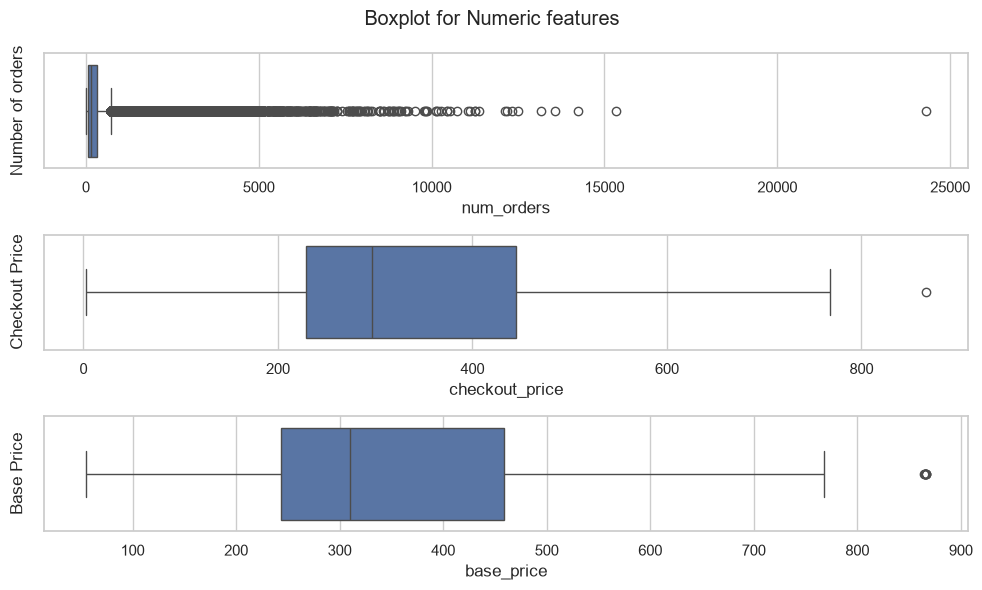

In [474]:
fig, ax = plt.subplots(nrows=3, figsize=(10,6))
sns.boxplot(data = df_train, x="num_orders", ax=ax[0])
sns.boxplot(data = df_train, x="checkout_price", ax=ax[1])
sns.boxplot(data = df_train, x="base_price", ax=ax[2])
ax[0].set_ylabel("Number of orders")
ax[1].set_ylabel("Checkout Price")
ax[2].set_ylabel("Base Price")
plt.suptitle("Boxplot for Numeric features")
plt.tight_layout()
plt.show()

In [475]:
print(df_train['num_orders'].quantile([0, 0.25, 0.5, 0.75, 1]))
iqr = df_train['num_orders'].quantile(0.75) - df_train['num_orders'].quantile(0.25)
upper_thresh = df_train['num_orders'].quantile(0.75) + iqr*1.5
print(iqr, upper_thresh)

0.00       13.0
0.25       54.0
0.50      136.0
0.75      324.0
1.00    24299.0
Name: num_orders, dtype: float64
270.0 729.0


In [476]:
df_train['num_orders_trimmed'] = (df_train['num_orders'].clip(upper=upper_thresh))
df_train.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area,num_orders_trimmed
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760,601.553399,56.614566,4.083590,221.65090
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798,66.195914,17.641306,1.091686,216.04962
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000,456.000000,23.000000,0.900000,13.00000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000,553.000000,34.000000,3.600000,54.00000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000,596.000000,56.000000,4.000000,136.00000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000,651.000000,77.000000,4.500000,324.00000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000,713.000000,93.000000,7.000000,729.00000


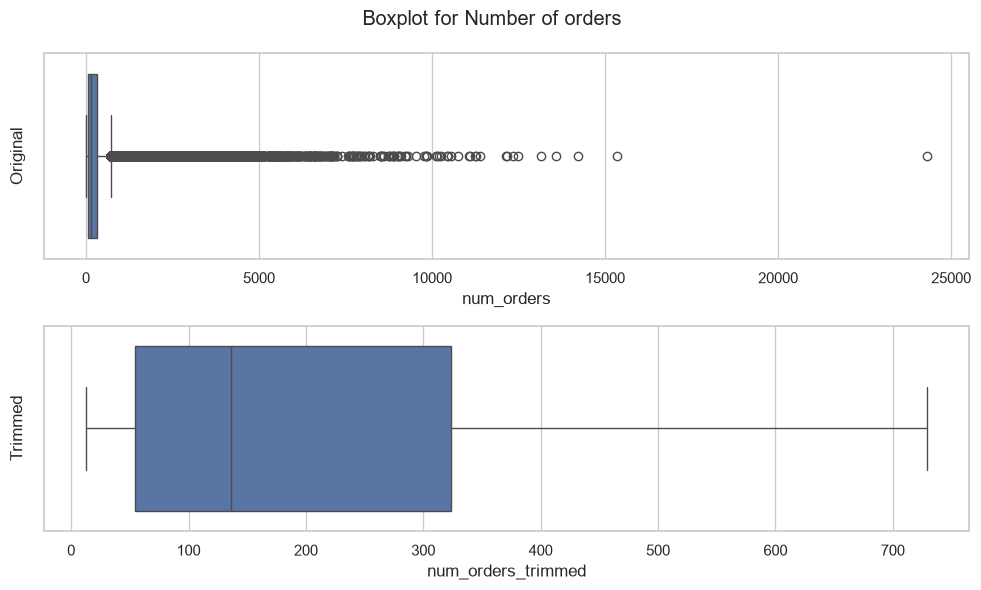

In [477]:
fig, ax = plt.subplots(nrows=2, figsize=(10,6))
sns.boxplot(data = df_train, x="num_orders", ax=ax[0])
sns.boxplot(data = df_train, x="num_orders_trimmed", ax=ax[1])
ax[0].set_ylabel("Original")
ax[1].set_ylabel("Trimmed")
plt.suptitle("Boxplot for Number of orders")
plt.tight_layout()
plt.show()

In [478]:
df_temp = df_train.groupby(by='city_code').agg({'region_code':'nunique'})
df_temp['region_code'].min(), df_temp['region_code'].max()

(np.int64(1), np.int64(1))

In [479]:
df_temp = df_train.groupby(by='city_code').agg({'op_area':'nunique'})
df_temp['op_area'].min(), df_temp['op_area'].max()

(np.int64(1), np.int64(9))

In [480]:
print(
    f"Cetners: {df_train['center_id'].nunique()},",
    f"Meals: {df_train['meal_id'].nunique()},",
    f"Cities: {df_train['city_code'].nunique()},",
    f"Regions: {df_train['region_code'].nunique()},",
    f"Operation Areas: {df_train['op_area'].nunique()},",
    f"Categories: {df_train['category'].nunique()},",
    f"Cuisine: {df_train['cuisine'].nunique()},",
    f"Weeks: {df_train['week'].max()}"
)

Cetners: 77, Meals: 51, Cities: 51, Regions: 8, Operation Areas: 30, Categories: 14, Cuisine: 4, Weeks: 145


In [481]:
df_train['grouped_cat'] = df_train.apply(lambda x: f"{x['city_code']}_{x['center_type']}_{x['op_area']}_{x['cuisine']}", axis=1)
df_test['grouped_cat'] = df_test.apply(lambda x: f"{x['city_code']}_{x['center_type']}_{x['op_area']}_{x['cuisine']}", axis=1)
df_grouped_tr = df_train.groupby(['city_code', 'center_type', 'op_area', 'cuisine', 'grouped_cat', 'week']).agg({'num_orders_trimmed': 'sum', 'id': 'count'}).reset_index()
df_grouped_ts = df_test.groupby(['city_code', 'center_type', 'op_area', 'cuisine', 'grouped_cat', 'week']).agg({'id': 'count'}).reset_index()
df_grouped_tr.head()

,city_code,center_type,op_area,cuisine,grouped_cat,week,num_orders_trimmed,id
0,456,TYPE_A,4.2,Continental,456_TYPE_A_4.2_Continental,1,2026,9
1,456,TYPE_A,4.2,Continental,456_TYPE_A_4.2_Continental,2,1785,9
2,456,TYPE_A,4.2,Continental,456_TYPE_A_4.2_Continental,3,1774,9
3,456,TYPE_A,4.2,Continental,456_TYPE_A_4.2_Continental,4,1799,9
4,456,TYPE_A,4.2,Continental,456_TYPE_A_4.2_Continental,5,1607,9


In [482]:
weeks = range(1, df_train['week'].max()+1)
df_forecastibility = (
    df_grouped_tr.groupby(['city_code', 'center_type', 'op_area', 'cuisine', 'grouped_cat'])
    .apply(lambda x: pd.Series({
        'total_obs': len(weeks),
        'non_zero_obs': (x['num_orders_trimmed'] >0).sum(),
        'ADI': (len(weeks)/(x['num_orders_trimmed']>0).sum() if (x['num_orders_trimmed']>0).any() else None),
        'CV2': (x.loc[x['num_orders_trimmed'] > 0, 'num_orders_trimmed'].std()/ x.loc[x['num_orders_trimmed'] > 0, 'num_orders_trimmed'].mean()) **2
    })).reset_index()
)
df_forecastibility['SBC'] = np.select(
    [
        (df_forecastibility['ADI'] < 1.32) & (df_forecastibility['CV2'] < 0.49),
        (df_forecastibility['ADI'] >= 1.32) & (df_forecastibility['CV2'] < 0.49),
        (df_forecastibility['ADI'] < 1.32) & (df_forecastibility['CV2'] >= 0.49),
        (df_forecastibility['ADI'] >= 1.32) & (df_forecastibility['CV2'] >= 0.49)
    ],
    ['Smooth', 'Intermittent', 'Erratic', 'Lumpy'],
    default='NA'
)
df_forecastibility.groupby(by='SBC').agg({'non_zero_obs': ['count', 'min', 'max', 'mean', 'median'] }).round(1)

non_zero_obs                            
              count    min    max   mean median
SBC                                            
Smooth          308  120.0  145.0  144.7  145.0

In [483]:
df_forecastibility.to_csv("./mywork/forecastibility_grouped1.csv", index=False)

In [484]:
# 'city_code', 'center_type', 'op_area', 'cuisine', 'grouped_cat'
def get_plot(data):
    city = data['city_code'].iat[0]
    center = data['center_type'].iat[0]
    op = data['op_area'].iat[0]
    cuisine = data['cuisine'].iat[0]

    sns.set_style("whitegrid")
    fig, ax_left = plt.subplots(figsize=(14, 6))

    sns.lineplot(data=data, x='week', y='num_orders_trimmed', ax=ax_left, label="No. of Orders", linewidth=2.5, marker='o')

    ax_left.set_ylabel("Number of Orders", color='tab:blue')
    ax_left.tick_params(axis='y', labelcolor='tab:blue')
    ax_left.set_xlabel('Weeks')
    ax_left.set_title(f"City: {city} | Center: {center} | Operation Area: {op} | Cuisine: {cuisine}")

    plt.show()

In [485]:
train_cat = list(df_train['grouped_cat'].unique())
test_cat = list(df_test['grouped_cat'].unique())
intersection = list(set(train_cat) & set(test_cat))
test_unique = [x for x in test_cat if x not in train_cat]
print(f"Train: {len(train_cat)}, Test: {len(test_cat)}, Intersections: {len(intersection)}, Test Unique: {len(test_unique)}")

Train: 308, Test: 308, Intersections: 308, Test Unique: 0


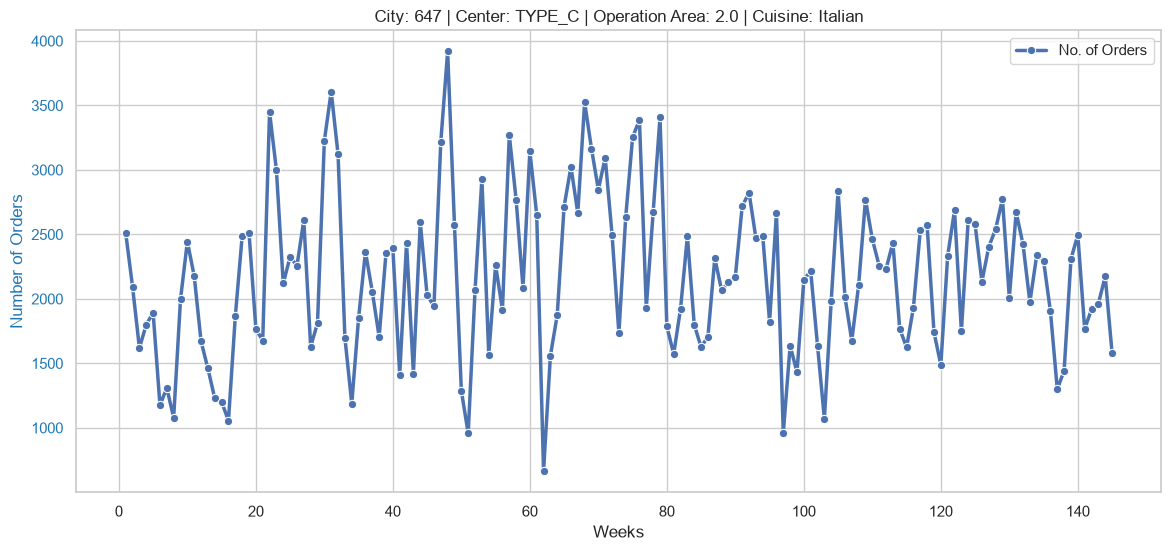

In [486]:
df_temp = df_grouped_tr[df_grouped_tr['grouped_cat']==train_cat[2]]
get_plot(df_temp)



## Smooth

#### Prepare the data for Forecasting
* Lets assume that the data is till December and we are using Monday to calculate date
* this is done so that we can use Prophet model
* Week 155 in dec means week 1 should fall in first monday of 2023 which is 2nd Jan 2023

In [487]:
first_monday = pd.Timestamp('2023-01-02')

# Create week -> date mapping
week_date_map = {week: first_monday + pd.Timedelta(weeks = week-1) for week in range(1, df_test['week'].max()+1)}
df_train['date'] = df_train['week'].map(week_date_map)
df_test['date'] = df_test['week'].map(week_date_map)
df_grouped_tr['date'] = df_grouped_tr['week'].map(week_date_map)
df_grouped_ts['date'] = df_grouped_ts['week'].map(week_date_map)

df_test.tail()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,city_code,region_code,center_type,op_area,category,cuisine,grouped_cat,date
32568,1250239,155,61,1543,482.09,484.09,0,0,473,77,TYPE_A,4.5,Desert,Indian,473_TYPE_A_4.5_Indian,2025-12-15
32569,1039516,155,61,2304,483.09,483.09,0,0,473,77,TYPE_A,4.5,Desert,Indian,473_TYPE_A_4.5_Indian,2025-12-15
32570,1158107,155,61,2664,322.07,323.07,0,0,473,77,TYPE_A,4.5,Salad,Italian,473_TYPE_A_4.5_Italian,2025-12-15
32571,1444235,155,61,2569,322.07,323.07,0,0,473,77,TYPE_A,4.5,Salad,Italian,473_TYPE_A_4.5_Italian,2025-12-15
32572,1291286,155,61,2490,276.45,276.45,0,0,473,77,TYPE_A,4.5,Salad,Italian,473_TYPE_A_4.5_Italian,2025-12-15


In [488]:
def preprocess_data(train_data, test_data, grouped_cat):
    df_tr = train_data[train_data['grouped_cat']==grouped_cat].rename(columns={'date': 'ds', 'num_orders_trimmed': 'y'}).reset_index(drop=True)
    df_ts = test_data[test_data['grouped_cat']==grouped_cat].rename(columns={'date': 'ds'}).reset_index(drop=True)

    return df_tr, df_ts

In [489]:
# 'city_code', 'center_type', 'op_area', 'cuisine', 'grouped_cat'
def train_prophet(df_tr, df_ts):
    performance_info={}
    if df_tr.shape[0]>0:
        m = Prophet()
        m.fit(df_tr)

        check_forecast = m.predict(df_tr)
        if 'yearly' in check_forecast.columns:
            required_cols = ['ds', 'trend', 'yearly', 'yhat']
        else:
            required_cols = ['ds', 'trend', 'yhat']
        df_tr = df_tr.merge(check_forecast[required_cols], on='ds', how='outer')
        if df_ts.shape[0]>0:
            forecast = m.predict(df_ts)
            df_ts = df_ts.merge(forecast[required_cols], on='ds', how='outer')
        performance_info = {
            'city_code': df_ts['city_code'].iat[0],
            'center_type': df_ts['center_type'].iat[0],
            'op_area': df_ts['op_area'].iat[0],
            'cuisine': df_ts['cuisine'].iat[0],
            'r2_score': r2_score(df_tr['y'], df_tr['yhat']),
            'mape': mean_absolute_percentage_error(df_tr['y'], df_tr['yhat']),
            'yearly': "true" if 'yearly' in required_cols else "false",
            'trend': "true" if check_forecast['trend'].sum()!=0 else "false",
            'train_data_len': df_tr.shape[0],
            'test_data_len': df_ts.shape[0]
        }
    return df_tr, df_ts, performance_info


In [490]:
performance_grouped, test_grouped, train_grouped = [], [], []
i=1
for cat in train_cat:
    df_temp, df_temp_ts = preprocess_data(df_grouped_tr, df_grouped_ts, cat)
    try:
        
        df_tr1, df_pred, info_dict = train_prophet(df_temp, df_temp_ts)
        performance_grouped.append(info_dict)
        test_grouped.append(df_pred)
        train_grouped.append(df_tr1)
        print(f"{i} of {len(train_cat)} {cat} done =================================================================================")
        
    except Exception as e:
        performance_grouped.append({
            'center_meal': cat,
            'r2_score': None,
            'mape': None,
            'train_data_len': df_temp.shape[0],
            'test_data_len': df_temp_ts.shape[0],
            'Error': str(e)
        })
        print(f"{i} of {len(cat)} {cat} Skipped !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
    i+=1
df_performance_grouped = pd.DataFrame(performance_grouped)
df_test_grouped = pd.concat(test_grouped, ignore_index=True)
df_train_grouped = pd.concat(train_grouped, ignore_index=True)

df_test_grouped.to_csv("./mywork/df_test_grouped.csv", index=False)
df_train_grouped.to_csv("./mywork/df_train_grouped.csv", index=False)
df_performance_grouped.to_csv("./mywork/prophet_performance_grouped.csv", index=False)

df_performance_grouped.tail()

22:40:04 - cmdstanpy - INFO - Chain [1] start processing
22:40:04 - cmdstanpy - INFO - Chain [1] done processing
22:40:04 - cmdstanpy - INFO - Chain [1] start processing
22:40:04 - cmdstanpy - INFO - Chain [1] done processing


1 of 308 647_TYPE_C_2.0_Thai done =================================================================================


22:40:04 - cmdstanpy - INFO - Chain [1] start processing
22:40:04 - cmdstanpy - INFO - Chain [1] done processing


2 of 308 647_TYPE_C_2.0_Indian done =================================================================================
3 of 308 647_TYPE_C_2.0_Italian done =================================================================================


22:40:05 - cmdstanpy - INFO - Chain [1] start processing
22:40:05 - cmdstanpy - INFO - Chain [1] done processing
22:40:05 - cmdstanpy - INFO - Chain [1] start processing
22:40:05 - cmdstanpy - INFO - Chain [1] done processing


...

22:41:16 - cmdstanpy - INFO - Chain [1] start processing
22:41:16 - cmdstanpy - INFO - Chain [1] done processing


306 of 308 473_TYPE_A_4.5_Indian done =================================================================================


22:41:16 - cmdstanpy - INFO - Chain [1] start processing
22:41:16 - cmdstanpy - INFO - Chain [1] done processing


307 of 308 473_TYPE_A_4.5_Italian done =================================================================================
308 of 308 473_TYPE_A_4.5_Continental done =================================================================================


,city_code,center_type,op_area,cuisine,r2_score,mape,yearly,trend,train_data_len,test_data_len
303,638,TYPE_A,7.0,Continental,0.408088,0.332806,true,true,145,10
304,473,TYPE_A,4.5,Thai,0.468573,0.111570,true,true,145,10
305,473,TYPE_A,4.5,Indian,0.380142,0.087630,true,true,145,10
306,473,TYPE_A,4.5,Italian,0.283438,0.148280,true,true,145,10
307,473,TYPE_A,4.5,Continental,0.401197,0.220958,true,true,145,10


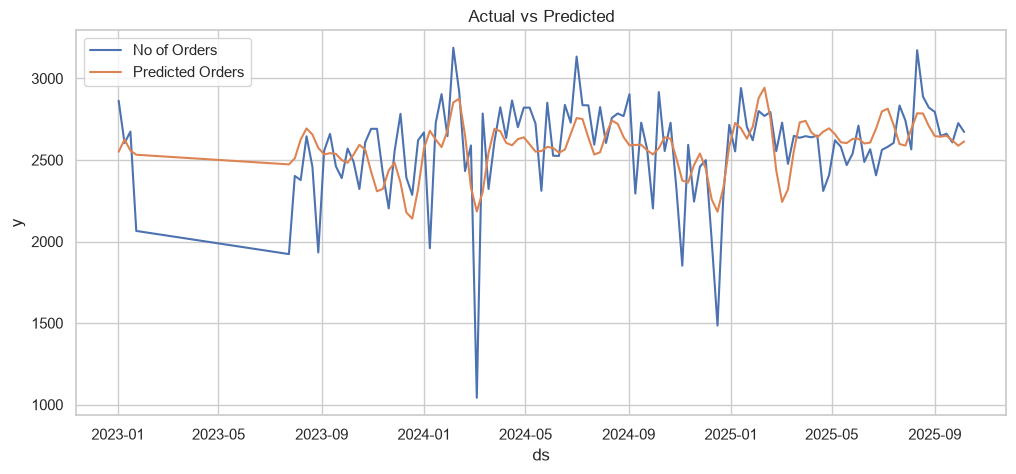

In [ ]:
ck = train_grouped[4]
plt.figure(figsize=(12,5))
sns.lineplot(data=ck, x='ds', y='y', label='No of Orders')
sns.lineplot(data=ck, x='ds', y='yhat', label='Predicted Orders')
plt.title("Actual vs Predicted")
plt.show()

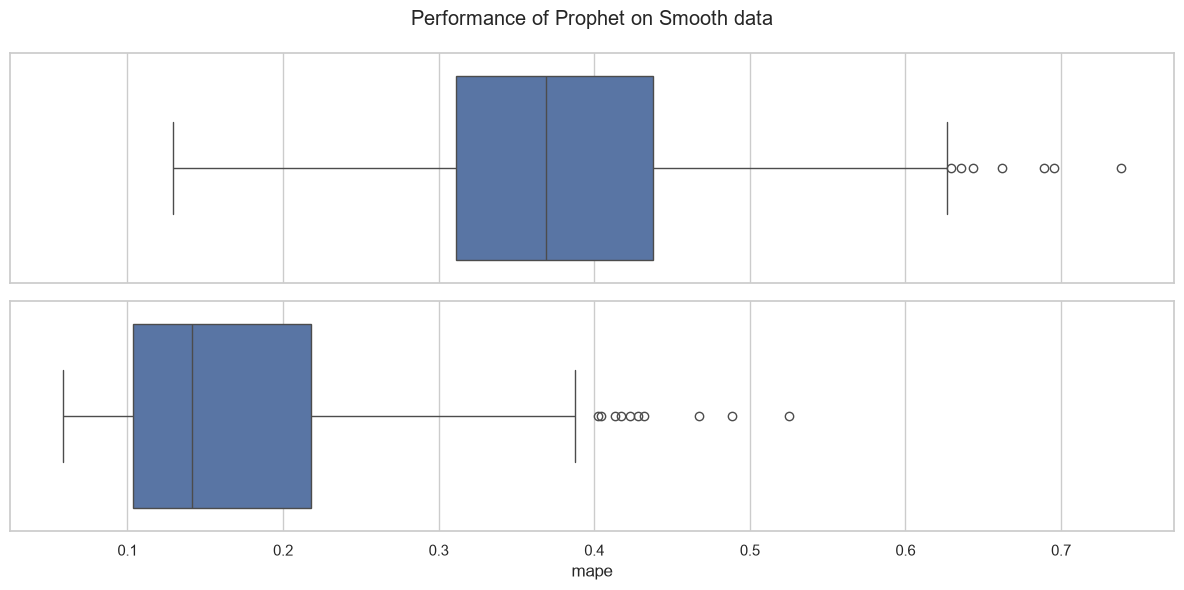

In [492]:
fig, ax = plt.subplots(nrows=2, figsize=(12,6), sharex=True)
sns.boxplot(data=df_performance_grouped, x='r2_score', ax=ax[0])
sns.boxplot(data=df_performance_grouped, x='mape', ax=ax[1])
fig.suptitle("Performance of Prophet on Smooth data")
plt.tight_layout()
plt.show()

In [493]:
df_train = df_train.merge(df_train_grouped[['grouped_cat', 'week', 'trend', 'yearly']], on=['grouped_cat', 'week'], how='left')
df_test = df_test.merge(df_test_grouped[['grouped_cat', 'week', 'trend', 'yearly']], on=['grouped_cat', 'week'], how='left')
print(df_train.isnull().sum(), df_test.isnull().sum())

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
num_orders_trimmed       0
grouped_cat              0
date                     0
trend                    0
yearly                   0
dtype: int64 id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
grouped_cat              0
date                     0
trend          

In [494]:
features = ['week', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'trend', 'yearly']

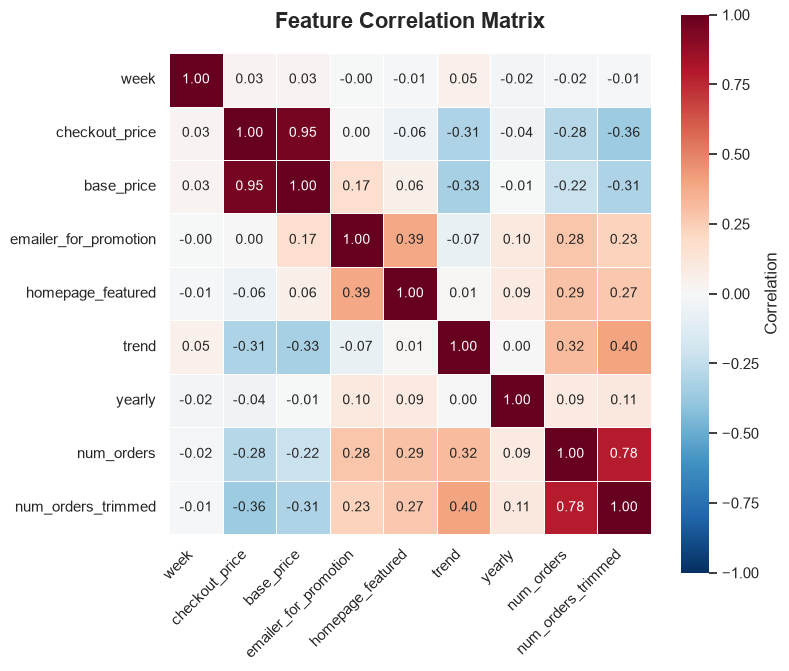

In [495]:
df_cor = df_train[features + ['num_orders', 'num_orders_trimmed']].corr('pearson')

plt.figure(figsize=(8,8))

sns.heatmap(
    df_cor,
    annot=True,             # Show correlation values
    fmt=".2f",
    cmap="RdBu_r",          # Blue = negative, Red = positive
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.7,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation"
    },
    annot_kws={"size": 10}
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=16,
    fontweight="bold",
    pad=18
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [496]:
X = df_train[features]
y = df_train['num_orders_trimmed']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (342411, 7), y_train: (342411,), X_test: (114137, 7), y_test: (114137,)


In [497]:
rf = RandomForestRegressor(n_estimators=200, n_jobs=-1)
rf.fit(X, y)
importances_rf = pd.DataFrame({
    'Features': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
importances_rf

,Features,Importance
1,checkout_price,0.281854
5,trend,0.244297
2,base_price,0.183342
0,week,0.118449
6,yearly,0.073324
3,emailer_for_promotion,0.052115
4,homepage_featured,0.046619


In [499]:
features = ['week', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'trend']

In [500]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [501]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 15],
    'subsample': [0.7, 0.85, 1.0]
}

gbc = GradientBoostingRegressor(random_state=42)
clf_gb = RandomizedSearchCV(gbc, gb_params, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1, random_state=42)

clf_gb.fit(X_train, y_train)

print("Best parameters:", clf_gb.best_params_)
print("Best CV score:", clf_gb.best_score_)

Best parameters: {'subsample': 0.7, 'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 15, 'max_depth': 4, 'learning_rate': 0.1}
Best CV score: -144.35697509747538


In [502]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None]
}

total_fits = cv.get_n_splits()
for param in rf_params.keys():
    total_fits *= len(rf_params[param])

rf = RandomForestRegressor(random_state=42)
clf_rf = RandomizedSearchCV(rf, rf_params, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1, random_state=42)

clf_rf.fit(X_train, y_train)

print("Best parameters:", clf_rf.best_params_)
print("Best CV score:", clf_rf.best_score_)

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV score: -115.39484795146018


In [504]:
models = {
    "Gradient Boosting": clf_gb,
    "Random Forest": clf_rf
}

results = {}

for name, model in models.items():

    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": 1-mean_absolute_percentage_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "R2 score": r2_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T

results_df

,Accuracy,MAPE,R2 score
Gradient Boosting,-0.337491,1.337491,0.553852
Random Forest,0.150592,0.849408,0.723399
